In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# 全局设置（中文+样式）
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

In [3]:
file_path = r'student_scores.csv'

df = pd.read_csv(
    file_path,
    encoding='utf-8',
    parse_dates=['考试日期']
)

df

,学号,姓名,班级,语文,数学,英语,物理,化学,考试日期
0,S001,张三,高一(1)班,85,92.0,78,88,90,2024-05-20
1,S002,李四,高一(1)班,76,88.0,85,79,82,2024-05-20
2,S003,王五,高一(1)班,90,NaN,89,91,88,2024-05-20
3,S004,赵六,高一(2)班,88,75.0,92,85,76,2024-05-20
4,S005,钱七,高一(2)班,65,58.0,72,68,70,2024-05-20
5,S006,孙八,高一(2)班,95,98.0,90,92,95,2024-05-20
6,S007,周九,高一(3)班,82,80.0,86,78,81,2024-05-20
7,S008,吴十,高一(3)班,58,62.0,65,59,61,2024-05-20
8,S009,郑十一,高一(3)班,88,90.0,85,90,87,2024-05-20
9,S010,冯十二,高一(1)班,105,89.0,91,87,89,2024-05-20


In [4]:
df.shape

(10, 9)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   学号      10 non-null     str           
 1   姓名      10 non-null     str           
 2   班级      10 non-null     str           
 3   语文      10 non-null     int64         
 4   数学      9 non-null      float64       
 5   英语      10 non-null     int64         
 6   物理      10 non-null     int64         
 7   化学      10 non-null     int64         
 8   考试日期    10 non-null     datetime64[us]
dtypes: datetime64[us](1), float64(1), int64(4), str(3)
memory usage: 852.0 bytes


In [6]:
df.isnull().sum()

学号      0
姓名      0
班级      0
语文      0
数学      1
英语      0
物理      0
化学      0
考试日期    0
dtype: int64

In [7]:
df[['语文', '数学', '英语', '物理', '化学']].describe()

,语文,数学,英语,物理,化学
count,10.00000,9.000000,10.000000,10.000000,10.00000
mean,83.20000,81.333333,83.300000,81.700000,81.90000
std,13.86282,13.829317,8.920015,10.873515,10.35428
min,58.00000,58.000000,65.000000,59.000000,61.00000
25%,77.50000,75.000000,79.750000,78.250000,77.25000
50%,86.50000,88.000000,85.500000,86.000000,84.50000
75%,89.50000,90.000000,89.750000,89.500000,88.75000
max,105.00000,98.000000,92.000000,92.000000,95.00000


In [8]:
df

,学号,姓名,班级,语文,数学,英语,物理,化学,考试日期
0,S001,张三,高一(1)班,85,92.0,78,88,90,2024-05-20
1,S002,李四,高一(1)班,76,88.0,85,79,82,2024-05-20
2,S003,王五,高一(1)班,90,NaN,89,91,88,2024-05-20
3,S004,赵六,高一(2)班,88,75.0,92,85,76,2024-05-20
4,S005,钱七,高一(2)班,65,58.0,72,68,70,2024-05-20
5,S006,孙八,高一(2)班,95,98.0,90,92,95,2024-05-20
6,S007,周九,高一(3)班,82,80.0,86,78,81,2024-05-20
7,S008,吴十,高一(3)班,58,62.0,65,59,61,2024-05-20
8,S009,郑十一,高一(3)班,88,90.0,85,90,87,2024-05-20
9,S010,冯十二,高一(1)班,105,89.0,91,87,89,2024-05-20


In [9]:
math_mean = df.groupby('班级')['数学'].transform('mean')
math_mean

0    89.666667
1    89.666667
2    89.666667
3    77.000000
4    77.000000
5    77.000000
6    77.333333
7    77.333333
8    77.333333
9    89.666667
Name: 数学, dtype: float64

In [10]:
df['数学'] = df['数学'].fillna(math_mean.round(1))
df

,学号,姓名,班级,语文,数学,英语,物理,化学,考试日期
0,S001,张三,高一(1)班,85,92.0,78,88,90,2024-05-20
1,S002,李四,高一(1)班,76,88.0,85,79,82,2024-05-20
2,S003,王五,高一(1)班,90,89.7,89,91,88,2024-05-20
3,S004,赵六,高一(2)班,88,75.0,92,85,76,2024-05-20
4,S005,钱七,高一(2)班,65,58.0,72,68,70,2024-05-20
5,S006,孙八,高一(2)班,95,98.0,90,92,95,2024-05-20
6,S007,周九,高一(3)班,82,80.0,86,78,81,2024-05-20
7,S008,吴十,高一(3)班,58,62.0,65,59,61,2024-05-20
8,S009,郑十一,高一(3)班,88,90.0,85,90,87,2024-05-20
9,S010,冯十二,高一(1)班,105,89.0,91,87,89,2024-05-20


In [11]:
df['语文'] = df['语文'].apply(lambda x: 100 if x > 100 else x)

df

,学号,姓名,班级,语文,数学,英语,物理,化学,考试日期
0,S001,张三,高一(1)班,85,92.0,78,88,90,2024-05-20
1,S002,李四,高一(1)班,76,88.0,85,79,82,2024-05-20
2,S003,王五,高一(1)班,90,89.7,89,91,88,2024-05-20
3,S004,赵六,高一(2)班,88,75.0,92,85,76,2024-05-20
4,S005,钱七,高一(2)班,65,58.0,72,68,70,2024-05-20
5,S006,孙八,高一(2)班,95,98.0,90,92,95,2024-05-20
6,S007,周九,高一(3)班,82,80.0,86,78,81,2024-05-20
7,S008,吴十,高一(3)班,58,62.0,65,59,61,2024-05-20
8,S009,郑十一,高一(3)班,88,90.0,85,90,87,2024-05-20
9,S010,冯十二,高一(1)班,100,89.0,91,87,89,2024-05-20


In [13]:
score_cols = ['语文', '数学', '英语', '物理', '化学']

In [14]:
df['总分'] = df[score_cols].sum(axis=1)
df['平均分'] = df[score_cols].mean(axis=1).round(1)
df['年级排名'] = df['总分'].rank(method='min', ascending=False).astype(int)
df['班级排名'] = df.groupby('班级')['总分'].rank(method='min', ascending=False).astype(int)

In [15]:
df

,学号,姓名,班级,语文,数学,英语,物理,化学,考试日期,总分,平均分,年级排名,班级排名
0,S001,张三,高一(1)班,85,92.0,78,88,90,2024-05-20,433.0,86.6,5,3
1,S002,李四,高一(1)班,76,88.0,85,79,82,2024-05-20,410.0,82.0,7,4
2,S003,王五,高一(1)班,90,89.7,89,91,88,2024-05-20,447.7,89.5,3,2
3,S004,赵六,高一(2)班,88,75.0,92,85,76,2024-05-20,416.0,83.2,6,2
4,S005,钱七,高一(2)班,65,58.0,72,68,70,2024-05-20,333.0,66.6,9,3
5,S006,孙八,高一(2)班,95,98.0,90,92,95,2024-05-20,470.0,94.0,1,1
6,S007,周九,高一(3)班,82,80.0,86,78,81,2024-05-20,407.0,81.4,8,2
7,S008,吴十,高一(3)班,58,62.0,65,59,61,2024-05-20,305.0,61.0,10,3
8,S009,郑十一,高一(3)班,88,90.0,85,90,87,2024-05-20,440.0,88.0,4,1
9,S010,冯十二,高一(1)班,100,89.0,91,87,89,2024-05-20,456.0,91.2,2,1


In [16]:
def get_grade(avg):
    if avg >= 90:
        return '优'
    elif avg >= 80:
        return '良'
    elif avg >= 70:
        return '中'
    elif avg >= 60:
        return '及格'
    else:
        return '不及格'

df['成绩等级'] = df['平均分'].apply(get_grade)
df

,学号,姓名,班级,语文,数学,英语,物理,化学,考试日期,总分,平均分,年级排名,班级排名,成绩等级
0,S001,张三,高一(1)班,85,92.0,78,88,90,2024-05-20,433.0,86.6,5,3,良
1,S002,李四,高一(1)班,76,88.0,85,79,82,2024-05-20,410.0,82.0,7,4,良
2,S003,王五,高一(1)班,90,89.7,89,91,88,2024-05-20,447.7,89.5,3,2,良
3,S004,赵六,高一(2)班,88,75.0,92,85,76,2024-05-20,416.0,83.2,6,2,良
4,S005,钱七,高一(2)班,65,58.0,72,68,70,2024-05-20,333.0,66.6,9,3,及格
5,S006,孙八,高一(2)班,95,98.0,90,92,95,2024-05-20,470.0,94.0,1,1,优
6,S007,周九,高一(3)班,82,80.0,86,78,81,2024-05-20,407.0,81.4,8,2,良
7,S008,吴十,高一(3)班,58,62.0,65,59,61,2024-05-20,305.0,61.0,10,3,及格
8,S009,郑十一,高一(3)班,88,90.0,85,90,87,2024-05-20,440.0,88.0,4,1,良
9,S010,冯十二,高一(1)班,100,89.0,91,87,89,2024-05-20,456.0,91.2,2,1,优


In [17]:
total_students = len(df)

In [18]:
total_students

10

In [19]:
pass_students = len(df[df['平均分'] >= 60])
pass_students

10

In [20]:
avg_total = df['总分'].mean().round(1)
avg_total

np.float64(411.8)

In [23]:
class_analysis = df.groupby('班级').agg(
    {
        '总分': ['mean', 'max', 'min'],
        '平均分': 'mean',
        '成绩等级': lambda x: (x == '优').sum()
    }
).round(1)

class_analysis.columns = ['班级平均分', '班级最高分', '班级最低分', '班级均分', '优等生数']
class_analysis

,班级平均分,班级最高分,班级最低分,班级均分,优等生数
班级,,,,,
高一(1)班,436.7,456.0,410.0,87.3,1
高一(2)班,406.3,470.0,333.0,81.3,1
高一(3)班,384.0,440.0,305.0,76.8,0


In [24]:
df

,学号,姓名,班级,语文,数学,英语,物理,化学,考试日期,总分,平均分,年级排名,班级排名,成绩等级
0,S001,张三,高一(1)班,85,92.0,78,88,90,2024-05-20,433.0,86.6,5,3,良
1,S002,李四,高一(1)班,76,88.0,85,79,82,2024-05-20,410.0,82.0,7,4,良
2,S003,王五,高一(1)班,90,89.7,89,91,88,2024-05-20,447.7,89.5,3,2,良
3,S004,赵六,高一(2)班,88,75.0,92,85,76,2024-05-20,416.0,83.2,6,2,良
4,S005,钱七,高一(2)班,65,58.0,72,68,70,2024-05-20,333.0,66.6,9,3,及格
5,S006,孙八,高一(2)班,95,98.0,90,92,95,2024-05-20,470.0,94.0,1,1,优
6,S007,周九,高一(3)班,82,80.0,86,78,81,2024-05-20,407.0,81.4,8,2,良
7,S008,吴十,高一(3)班,58,62.0,65,59,61,2024-05-20,305.0,61.0,10,3,及格
8,S009,郑十一,高一(3)班,88,90.0,85,90,87,2024-05-20,440.0,88.0,4,1,良
9,S010,冯十二,高一(1)班,100,89.0,91,87,89,2024-05-20,456.0,91.2,2,1,优


In [25]:
subject_avg = df[score_cols].mean().round(1)

In [26]:
subject_avg

语文    82.7
数学    82.2
英语    83.3
物理    81.7
化学    81.9
dtype: float64

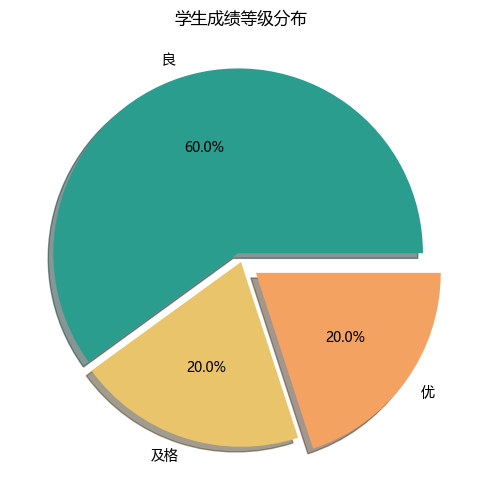

In [28]:
grade_count = df['成绩等级'].value_counts()
plt.figure(figsize=(8, 6))

explode = [0] * len(grade_count)
if len(explode) >= 1:
    explode[0] = 0.05   # 突出第一个等级
if len(explode) >= 2:
    explode[-1] = 0.1   # 突出最后一个等级

plt.pie(
    grade_count.values,
    labels=grade_count.index,
    autopct='%1.1f%%',
    colors=['#2A9D8F', '#E9C46A', '#F4A261', '#E76F51', '#9E2A2B'],
    explode=explode,  # 突出优和不及格
    shadow=True)
plt.title('学生成绩等级分布')
plt.show()

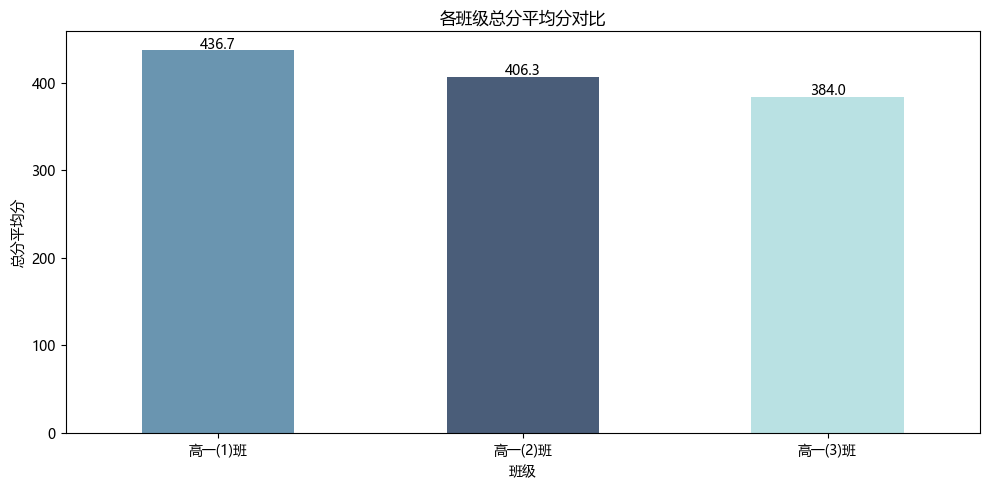

In [29]:
plt.figure(figsize=(10, 5))
class_total = df.groupby('班级')['总分'].mean()
class_total.plot(
    kind='bar',
    color=['#457B9D', '#1D3557', '#A8DADC'],
    alpha=0.8)
plt.title('各班级总分平均分对比')
plt.xlabel('班级')
plt.ylabel('总分平均分')
plt.xticks(rotation=0)
# 添加数值标签
for i, v in enumerate(class_total):
    plt.text(i, v+2, f'{v:.1f}', ha='center')
plt.tight_layout()
plt.show()

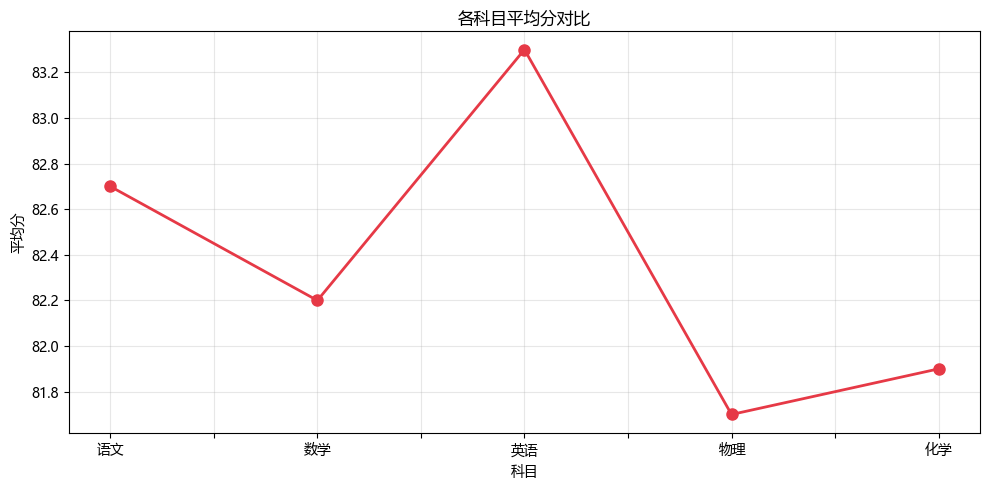

In [30]:
plt.figure(figsize=(10, 5))
subject_avg.plot(
    kind='line',
    marker='o',
    markersize=8,
    linewidth=2,
    color='#E63946')
plt.title('各科目平均分对比')
plt.xlabel('科目')
plt.ylabel('平均分')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [31]:
df.to_excel('学生成绩清洗后数据.xlsx', index=False)
class_analysis.to_excel('班级成绩分析结果.xlsx')
print("\n5. 分析结果已导出为Excel文件！")


5. 分析结果已导出为Excel文件！
